# Entendimiento de los Datos — Censo 2024 INE Bolivia

## 1. Contexto del proyecto

Este proyecto estudiará el acceso a agua, saneamiento, energía eléctrica e internet mediante microdatos del Censo de Población y Vivienda 2024 de Bolivia. Buscamos identificar la precariedad en servicios básicos y examinar su distribución territorial por área urbana o rural, departamento y municipio. Los resultados deberán derivarse de los microdatos oficiales, sin utilizar cifras inventadas.

## 2. Fuente de los datos

La fuente prevista es el Instituto Nacional de Estadística de Bolivia (INE), a través de los microdatos oficiales del Censo de Población y Vivienda 2024. Antes del análisis se documentarán los archivos obtenidos, su procedencia y la documentación que los acompaña.

## 3. Unidad de análisis

El archivo y el diccionario corresponden a la entidad **VIVIENDA**. El cuestionario comienza con la ubicación y tipo de vivienda, y luego pregunta por los servicios de la vivienda y los bienes de «su hogar». La estructura del CSV y la unicidad de `i00` se comprueban abajo. La equivalencia entre vivienda y hogar no se da por supuesta: preguntas como «baño compartido con otros hogares» muestran que pueden diferir. Para estudiar servicios de agua, saneamiento y electricidad, la vivienda es la unidad primaria documentada; para internet y bienes se debe revisar el alcance de las preguntas de hogar. Este archivo no muestra una columna explícita de número de hogar. El análisis principal de servicios puede comenzar con VIVIENDA; Persona solo sería necesario para preguntas individuales o para validar composición y vínculos entre hogares y viviendas.

## 4. Carga e inspección inicial de los datos

Verificamos primero los archivos, el tamaño, la codificación y el separador. Conservaremos los códigos como texto para no perder ceros iniciales. La ruta `data/` es relativa al directorio desde el que se abre este notebook.

In [1]:
from pathlib import Path
import csv
import pandas as pd
import numpy as np

data_dir = Path("data")
csv_path = data_dir / "Vivienda_CPV-2024.csv"
dic_path = data_dir / "Diccionario de variables CPV 2024.xlsx"
pdf_path = data_dir / "Cuestionario censal 2024.pdf"
for archivo in (csv_path, dic_path, pdf_path):
    print(f"{archivo}: existe={archivo.is_file()}, tamaño={archivo.stat().st_size / 1024**2:.2f} MiB")

with csv_path.open("rb") as archivo:
    muestra_bytes = archivo.read(65536)
for codificacion in ("utf-8-sig", "utf-8", "cp1252"):
    try:
        muestra_texto = muestra_bytes.decode(codificacion)
        break
    except UnicodeDecodeError:
        continue
separador = csv.Sniffer().sniff(muestra_texto, delimiters=";,\t|").delimiter
with csv_path.open(encoding=codificacion, newline="") as archivo:
    lector = csv.reader(archivo, delimiter=separador)
    columnas = next(lector)
    primeras_filas_crudas = [next(lector) for _ in range(5)]
print("Codificación compatible en la muestra:", codificacion)
print("Separador:", repr(separador))
print("Columnas:", columnas)
print("Primeras dos filas crudas:", primeras_filas_crudas[:2])

data/Vivienda_CPV-2024.csv: existe=True, tamaño=468.12 MiB
data/Diccionario de variables CPV 2024.xlsx: existe=True, tamaño=0.20 MiB
data/Cuestionario censal 2024.pdf: existe=True, tamaño=20.10 MiB
Codificación compatible en la muestra: utf-8-sig
Separador: ';'
Columnas: ['idep', 'iprov', 'imun', 'i00', 'urbrur', 'v01_tipoviv', 'v02_condocup', 'v03_pared', 'v04_revoq', 'v05_techo', 'v06_piso', 'v07_aguapro', 'v08_aguadist', 'v09_energia', 'v10_combus', 'v11_basura', 'v12_cocina', 'v13_habitac', 'v14_dormit', 'v15_servsan', 'v16_desague', 'v17_tenencia', 'v18a_bici', 'v18b_moto', 'v18c_auto', 'v18d_carreta', 'v18e_bote', 'v18f_refri', 'v18g_micro', 'v18h_calefon', 'v18i_aire', 'v18j_lavadora', 'v19a_radio', 'v19b_tv', 'v19c_compu', 'v19d_celular', 'v19e_inetfijo', 'v19f_inetmovil', 'v19g_tvcable', 'v19h_telfijo', 'v20a_emi', 'v20b_totemi', 'v21a_fal', 'v21b_totfal', 'tot_pers', 'tip_hog', 'v19e_f', 'v19h_d']
Primeras dos filas crudas: [['01', '05', '02', '03234684', '2', '16', '', '', '

La codificación indicada es compatible con la muestra inicial; la lectura completa verificará el resto del archivo. Las filas crudas permiten ver vacíos y ceros iniciales antes de cualquier inferencia de tipos.

### 4.1 Dimensiones del dataset

Contamos registros y columnas con pandas. Leemos por bloques de 50.000 filas para limitar el uso de memoria; reunimos conteos y huellas de filas, sin conservar copias del dataset completo. Todos los campos se leen como texto para preservar los códigos originales.

In [2]:
from collections import Counter

tamano_bloque = 50_000
faltantes = pd.Series(0, index=columnas, dtype="int64")
observados = {col: set() for col in columnas if col != "i00"}
huellas_i00 = []
huellas_filas = []
filas = 0
memoria_bloques = []
vista = None
for bloque in pd.read_csv(csv_path, sep=separador, encoding=codificacion,
                          dtype="string", chunksize=tamano_bloque):
    if vista is None:
        vista = bloque.head(5).copy()
    filas += len(bloque)
    faltantes += bloque.isna().sum()
    memoria_bloques.append(bloque.memory_usage(deep=True).sum())
    for col in observados:
        observados[col].update(bloque[col].dropna().unique().tolist())
    huellas_i00.append(pd.util.hash_pandas_object(bloque["i00"], index=False).to_numpy())
    huellas_filas.append(pd.util.hash_pandas_object(bloque, index=False).to_numpy())

huellas_i00 = np.concatenate(huellas_i00)
huellas_filas = np.concatenate(huellas_filas)
valores_unicos = pd.Series({col: (np.unique(huellas_i00).size if col == "i00" else len(observados[col]))
                            for col in columnas}, name="valores_unicos")
duplicados_por_huella = int(filas - np.unique(huellas_filas).size)
print("Filas:", filas)
print("Columnas:", len(columnas))
print("Memoria máxima observada de un bloque:", f"{max(memoria_bloques) / 1024**2:.1f} MiB")
print("Estimación si se cargara todo como texto:", f"{sum(memoria_bloques) / 1024**2:.1f} MiB")
print("Datos retenidos: cinco filas, agregados y huellas de 64 bits; no el CSV completo.")

Filas: 4490488
Columnas: 48
Memoria máxima observada de un bloque: 119.3 MiB
Estimación si se cargara todo como texto: 10561.9 MiB
Datos retenidos: cinco filas, agregados y huellas de 64 bits; no el CSV completo.


La estimación de memoria suma el tamaño medido de los bloques en pandas; no representa memoria usada simultáneamente. Las huellas de 64 bits permiten contar candidatos a duplicado, que se contrastan más adelante.

### 4.2 Vista preliminar

Mostramos las primeras cinco filas reales para comprobar el contenido y la presencia de campos vacíos, sin interpretar todavía sus códigos.

In [3]:
display(vista)

,idep,iprov,imun,i00,urbrur,v01_tipoviv,v02_condocup,v03_pared,v04_revoq,v05_techo,...,v19g_tvcable,v19h_telfijo,v20a_emi,v20b_totemi,v21a_fal,v21b_totfal,tot_pers,tip_hog,v19e_f,v19h_d
0,01,05,02,03234684,2,16,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,<NA>,<NA>,<NA>
1,01,01,01,03456486,1,16,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,4,<NA>,<NA>,<NA>
2,01,01,01,03403778,1,15,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,<NA>,<NA>,<NA>
3,01,09,03,01872401,2,1,2,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,<NA>,<NA>,<NA>
4,01,07,01,03466651,2,1,2,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,<NA>,<NA>,<NA>


Las primeras filas son una vista de inspección. Los campos vacíos y los códigos necesitan el diccionario y las reglas de salto del cuestionario para interpretarse.

### 4.3 Tipos de datos

Mostramos el tipo de lectura y la cantidad de valores distintos de cada campo. El tipo `string` es deliberado: los códigos, incluidos los geográficos, no son magnitudes continuas.

In [4]:
display(pd.DataFrame({"tipo_pandas": vista.dtypes.astype(str), "valores_unicos": valores_unicos}).rename_axis("variable"))

,tipo_pandas,valores_unicos
variable,,
idep,string,9
iprov,string,20
imun,string,8
i00,string,4490488
urbrur,string,2
v01_tipoviv,string,16
v02_condocup,string,6
v03_pared,string,7
v04_revoq,string,2


La tabla informa el tipo usado en esta lectura y la cardinalidad observada en el CSV completo. No convierte ni recodifica ninguna variable.

### 4.4 Diccionario de variables

Leemos las cuatro hojas del diccionario oficial. En la hoja VIVIENDA, cada variable ocupa un bloque de filas con etiqueta, nombre, tipo, rango y posibles códigos. Unimos la documentación al CSV por el nombre real de la columna.

In [5]:
libro = pd.ExcelFile(dic_path)
print("Hojas del diccionario:", libro.sheet_names)
dic_hojas = {nombre: pd.read_excel(libro, sheet_name=nombre, header=None, dtype="string")
             for nombre in libro.sheet_names}
print("Filas y columnas de cada hoja:", {nombre: tabla.shape for nombre, tabla in dic_hojas.items()})

tabla_viv = dic_hojas["VIVIENDA"]
registros_dic = []
actual = None
for fila in tabla_viv.itertuples(index=False, name=None):
    etiqueta = str(fila[1]).strip() if pd.notna(fila[1]) else ""
    dato = str(fila[2]).strip() if pd.notna(fila[2]) else ""
    if etiqueta == "Etiqueta":
        descripcion = dato
    elif etiqueta == "Nombre":
        actual = {"variable_dic": dato, "descripcion_oficial": descripcion,
                  "tipo_oficial": "", "rango_oficial": "", "codigos": {}}
        registros_dic.append(actual)
    elif etiqueta == "Tipo" and actual is not None:
        actual["tipo_oficial"] = dato
        actual["rango_oficial"] = str(fila[4]).strip() if pd.notna(fila[4]) else ""
    elif actual is not None and etiqueta not in ("", "Categorías") and pd.notna(fila[2]):
        actual["codigos"][etiqueta] = dato

dic_por_columna = {r["variable_dic"].lower(): r for r in registros_dic}
print("Variables documentadas en VIVIENDA:", len(registros_dic))
print("Columnas del CSV presentes en VIVIENDA:", sum(c in dic_por_columna for c in columnas), "de", len(columnas))
print("Columnas sin ficha en VIVIENDA:", [c for c in columnas if c not in dic_por_columna])
display(pd.DataFrame([{"variable": c, "descripcion_oficial": dic_por_columna[c]["descripcion_oficial"],
                       "tipo_oficial": dic_por_columna[c]["tipo_oficial"],
                       "rango_oficial": dic_por_columna[c]["rango_oficial"],
                       "codigos_y_etiquetas": dic_por_columna[c]["codigos"]}
                      for c in columnas if c in dic_por_columna]))

Hojas del diccionario: ['PERSONA', 'VIVIENDA', 'EMIGRA', 'MORTA']
Filas y columnas de cada hoja: {'PERSONA': (5616, 9), 'VIVIENDA': (408, 9), 'EMIGRA': (285, 9), 'MORTA': (58, 9)}
Variables documentadas en VIVIENDA: 44
Columnas del CSV presentes en VIVIENDA: 44 de 48
Columnas sin ficha en VIVIENDA: ['idep', 'iprov', 'imun', 'i00']


,variable,descripcion_oficial,tipo_oficial,rango_oficial,codigos_y_etiquetas
0,urbrur,Área Urbana - Rural,INTEGER,1 - 2,"{'1': 'Urbana', '2': 'Rural'}"
1,v01_tipoviv,1. La vivienda es: (Tipo de vivienda),INTEGER,1 - 16,"{'1': 'Casa', '2': 'Choza, pahuichi', '3': 'De..."
2,v02_condocup,2. La vivienda esta: (Condición de ocupación d...,INTEGER,0 - 5,{'0': 'Ocupada con personas presentes sin Jefe...
3,v03_pared,3. Cual es el material de construcción más uti...,INTEGER,1 - 7,"{'1': 'Ladrillo, bloque de cemento, hormigón',..."
4,v04_revoq,4. Las paredes interiores de esta vivienda. Ti...,INTEGER,1 - 2,"{'1': 'Sí', '2': 'No'}"
5,v05_techo,5. Cuál es el material de construcción más uti...,INTEGER,1 - 5,"{'1': 'Calamina o plancha', '2': 'Teja (de cem..."
6,v06_piso,6. Cuál es el material más utilizado en los pi...,INTEGER,1 - 9,"{'1': 'Tierra', '2': 'Tablón de madera', '3': ..."
7,v07_aguapro,"7. Principalmente, el agua que usan en la vivi...",INTEGER,1 - 9,"{'1': 'Cañería de red', '2': 'Pileta pública',..."
8,v08_aguadist,8. El agua que usan en la vivienda se distribuye:,INTEGER,1 - 3,"{'1': 'Por cañería dentro de la vivienda', '2'..."
9,v09_energia,9. De donde proviene la energía eléctrica que ...,INTEGER,1 - 5,"{'1': 'Servicio público de energía eléctrica',..."


Las etiquetas de la tabla provienen de la hoja oficial VIVIENDA. Las columnas sin ficha se mantienen señaladas como no documentadas en esa hoja; sus nombres no se usarán para asignarles un significado que el archivo no confirme.

Comprobamos identificadores y cobertura de las cuatro dimensiones de servicios. Mostramos tanto los códigos documentados como los observados, para no confundir categorías posibles con categorías presentes.

In [6]:
identificadores = [c for c in ["idep", "iprov", "imun", "i00", "urbrur"] if c in columnas]
display(pd.DataFrame([{"variable": c,
                       "descripcion_oficial": dic_por_columna.get(c, {}).get("descripcion_oficial", "Sin ficha en VIVIENDA"),
                       "tipo_pandas": str(vista[c].dtype), "valores_unicos": int(valores_unicos[c]),
                       "ejemplos": sorted(observados[c])[:10] if c in observados else vista[c].dropna().head(10).tolist(),
                       "longitudes_observadas": sorted({len(x) for x in observados[c]}) if c in observados else sorted({len(x) for x in vista[c].dropna()})}
                      for c in identificadores]))

dimensiones = {
    "Agua": ["v07_aguapro", "v08_aguadist"],
    "Saneamiento": ["v15_servsan", "v16_desague"],
    "Electricidad": ["v09_energia"],
    "Internet": ["v19e_inetfijo", "v19f_inetmovil", "v19e_f"],
}
tabla_servicios = pd.DataFrame([
    {"dimension": dimension, "variable_real": c,
     "descripcion_oficial": dic_por_columna[c]["descripcion_oficial"],
     "codigos_disponibles": list(dic_por_columna[c]["codigos"]),
     "significado_de_codigos": dic_por_columna[c]["codigos"],
     "observacion": "Presente en el CSV; criterios de carencia pendientes"}
    for dimension, cols in dimensiones.items() for c in cols
    if c in columnas and c in dic_por_columna
])
display(tabla_servicios)

complementarias = [c for c in columnas if c.startswith(("v01_", "v02_", "v03_", "v04_", "v05_", "v06_", "v10_", "v11_", "v12_", "v13_", "v14_", "v17_", "v18", "v19", "tip_hog", "tot_pers"))]
display(pd.DataFrame([{"variable": c, "descripcion_oficial": dic_por_columna.get(c, {}).get("descripcion_oficial", "Sin ficha en VIVIENDA"),
                       "codigos_y_etiquetas": dic_por_columna.get(c, {}).get("codigos", {})}
                      for c in complementarias]))

display(pd.DataFrame([{"dimension": dim, "variables_disponibles": [c for c in cols if c in columnas and c in dic_por_columna],
                       "es_medible": all(c in columnas and c in dic_por_columna for c in cols),
                       "pendiente": "Definir población aplicable, tratamiento de códigos especiales y criterio de carencia"}
                      for dim, cols in dimensiones.items()]))

,variable,descripcion_oficial,tipo_pandas,valores_unicos,ejemplos,longitudes_observadas
0,idep,Sin ficha en VIVIENDA,string,9,"[01, 02, 03, 04, 05, 06, 07, 08, 09]",[2]
1,iprov,Sin ficha en VIVIENDA,string,20,"[01, 02, 03, 04, 05, 06, 07, 08, 09, 10]",[2]
2,imun,Sin ficha en VIVIENDA,string,8,"[01, 02, 03, 04, 05, 06, 07, 08]",[2]
3,i00,Sin ficha en VIVIENDA,string,4490488,"[03234684, 03456486, 03403778, 01872401, 03466...",[8]
4,urbrur,Área Urbana - Rural,string,2,"[1, 2]",[1]


,dimension,variable_real,descripcion_oficial,codigos_disponibles,significado_de_codigos,observacion
0,Agua,v07_aguapro,"7. Principalmente, el agua que usan en la vivi...","[1, 2, 3, 4, 5, 6, 7, 8, 9]","{'1': 'Cañería de red', '2': 'Pileta pública',...",Presente en el CSV; criterios de carencia pend...
1,Agua,v08_aguadist,8. El agua que usan en la vivienda se distribuye:,"[1, 2, 3]","{'1': 'Por cañería dentro de la vivienda', '2'...",Presente en el CSV; criterios de carencia pend...
2,Saneamiento,v15_servsan,"15. Tienen, baño o letrina","[1, 2, 3]","{'1': 'Sí, usado solo por su hogar', '2': 'Sí,...",Presente en el CSV; criterios de carencia pend...
3,Saneamiento,v16_desague,16. El baño o letrina tiene desagüe:,"[1, 2, 3, 4, 5, 6]","{'1': 'A la red de alcantarillado', '2': 'A un...",Presente en el CSV; criterios de carencia pend...
4,Electricidad,v09_energia,9. De donde proviene la energía eléctrica que ...,"[1, 2, 3, 4, 5]","{'1': 'Servicio público de energía eléctrica',...",Presente en el CSV; criterios de carencia pend...
5,Internet,v19e_inetfijo,19.5. Su hogar tiene: Internet fijo en la vivi...,"[1, 2, 9]","{'1': 'Sí', '2': 'No', '9': 'Sin especificar'}",Presente en el CSV; criterios de carencia pend...
6,Internet,v19f_inetmovil,19.6. Su hogar tiene: Internet móvil (megas o ...,"[1, 2, 9]","{'1': 'Sí', '2': 'No', '9': 'Sin especificar'}",Presente en el CSV; criterios de carencia pend...
7,Internet,v19e_f,Internet fijo en la vivienda o internet móvil,"[1, 2, 9]","{'1': 'Sí', '2': 'No', '9': 'Sin especificar'}",Presente en el CSV; criterios de carencia pend...


,variable,descripcion_oficial,codigos_y_etiquetas
0,v01_tipoviv,1. La vivienda es: (Tipo de vivienda),"{'1': 'Casa', '2': 'Choza, pahuichi', '3': 'De..."
1,v02_condocup,2. La vivienda esta: (Condición de ocupación d...,{'0': 'Ocupada con personas presentes sin Jefe...
2,v03_pared,3. Cual es el material de construcción más uti...,"{'1': 'Ladrillo, bloque de cemento, hormigón',..."
3,v04_revoq,4. Las paredes interiores de esta vivienda. Ti...,"{'1': 'Sí', '2': 'No'}"
4,v05_techo,5. Cuál es el material de construcción más uti...,"{'1': 'Calamina o plancha', '2': 'Teja (de cem..."
5,v06_piso,6. Cuál es el material más utilizado en los pi...,"{'1': 'Tierra', '2': 'Tablón de madera', '3': ..."
6,v10_combus,10. Cuál es el principal combustible o energía...,"{'1': 'Gas en garrafa', '2': 'Gas por cañería ..."
7,v11_basura,11. Habitualmente. Qué hacen con la basura que...,{'1': 'La depositan en el contenedor o basurer...
8,v12_cocina,12. Tienen un cuarto solo para cocinar,"{'1': 'Sí', '2': 'No'}"
9,v13_habitac,"13. Cuántos cuartos o habitaciones ocupan, sin...","{'1': 'Uno', '2': 'Dos', '3': 'Tres', '4': 'Cu..."


,dimension,variables_disponibles,es_medible,pendiente
0,Agua,"[v07_aguapro, v08_aguadist]",True,"Definir población aplicable, tratamiento de có..."
1,Saneamiento,"[v15_servsan, v16_desague]",True,"Definir población aplicable, tratamiento de có..."
2,Electricidad,[v09_energia],True,"Definir población aplicable, tratamiento de có..."
3,Internet,"[v19e_inetfijo, v19f_inetmovil, v19e_f]",True,"Definir población aplicable, tratamiento de có..."


La disponibilidad de variables permite estudiar las cuatro dimensiones. La tabla no define aún qué categoría constituye carencia ni calcula el IPS. `idep`, `iprov`, `imun` e `i00` no tienen ficha en la hoja VIVIENDA; la estructura de sus códigos requiere validación adicional antes de asignarles una etiqueta geográfica definitiva.

## 5. Calidad de los datos

### 5.1 Valores faltantes

Contamos valores que pandas reconoce como ausentes y su porcentaje sobre todas las filas. El cuestionario tiene preguntas condicionadas, por lo que un campo vacío puede corresponder a una pregunta no aplicable; NaN no equivale automáticamente a falta de respuesta.

In [7]:
display(pd.DataFrame({"NaN": faltantes, "porcentaje_NaN": (faltantes / filas * 100).round(4)}).rename_axis("variable"))

,NaN,porcentaje_NaN
variable,,
idep,0,0.0000
iprov,0,0.0000
imun,0,0.0000
i00,0,0.0000
urbrur,0,0.0000
v01_tipoviv,0,0.0000
v02_condocup,26715,0.5949
v03_pared,866777,19.3025
v04_revoq,866777,19.3025


Este diagnóstico conserva todas las filas. La interpretación de cada vacío debe comprobarse con el flujo del cuestionario y los códigos especiales del diccionario antes de decidir cualquier tratamiento.

### 5.2 Registros duplicados

Revisamos filas completas idénticas mediante huellas calculadas sobre todas las columnas. Si hay huellas repetidas, se comprueban las filas candidatas mediante una segunda lectura para obtener el conteo exacto.

In [8]:
if duplicados_por_huella == 0:
    duplicados_exactos = 0
else:
    huellas_repetidas = np.unique(huellas_filas, return_counts=True)
    candidatos = set(huellas_repetidas[0][huellas_repetidas[1] > 1].tolist())
    filas_candidatas = []
    for bloque in pd.read_csv(csv_path, sep=separador, encoding=codificacion,
                              dtype="string", chunksize=tamano_bloque):
        mascara = pd.util.hash_pandas_object(bloque, index=False).isin(candidatos)
        if mascara.any():
            filas_candidatas.append(bloque.loc[mascara])
    duplicados_exactos = int(pd.concat(filas_candidatas, ignore_index=True).duplicated().sum())
print("Filas completamente duplicadas:", duplicados_exactos)
print("Valores distintos de i00:", int(valores_unicos["i00"]))
print("Filas que comparten valor de i00:", filas - int(valores_unicos["i00"]))

Filas completamente duplicadas: 0
Valores distintos de i00: 4490488
Filas que comparten valor de i00: 0


El recuento se refiere a filas idénticas en todas sus columnas. Compartir un identificador es una pregunta distinta: se presenta por separado y no se elimina ningún registro.

### 5.3 Valores y códigos categóricos

Comparamos códigos efectivamente presentes con las categorías enumeradas en el diccionario. Los códigos como “Sin especificar” son especiales aunque pandas no los marque como NaN. Un rango oficial sin lista de categorías no permite declarar un valor inválido por sí solo.

In [9]:
codigos_especiales = []
comparacion_codigos = []
for c in columnas:
    if c not in dic_por_columna or c not in observados:
        continue
    etiquetas = dic_por_columna[c]["codigos"]
    presentes = observados[c]
    no_documentados = sorted(presentes - set(etiquetas), key=lambda x: (len(x), x)) if etiquetas else []
    comparacion_codigos.append({"variable": c, "codigos_observados": sorted(presentes, key=lambda x: (len(x), x)),
                                "codigos_documentados": etiquetas,
                                "fuera_de_lista": no_documentados})
    for codigo, significado in etiquetas.items():
        if any(palabra in significado.lower() for palabra in ("sin especificar", "no sabe", "sin respuesta", "ignorado", "no aplica")):
            codigos_especiales.append({"variable": c, "codigo": codigo, "etiqueta_oficial": significado,
                                      "observado": codigo in presentes})
display(pd.DataFrame(comparacion_codigos))
display(pd.DataFrame(codigos_especiales))

,variable,codigos_observados,codigos_documentados,fuera_de_lista
0,urbrur,"[1, 2]","{'1': 'Urbana', '2': 'Rural'}",[]
1,v01_tipoviv,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'1': 'Casa', '2': 'Choza, pahuichi', '3': 'De...",[]
2,v02_condocup,"[0, 1, 2, 3, 4, 5]",{'0': 'Ocupada con personas presentes sin Jefe...,[]
3,v03_pared,"[1, 2, 3, 4, 5, 6, 7]","{'1': 'Ladrillo, bloque de cemento, hormigón',...",[]
4,v04_revoq,"[1, 2]","{'1': 'Sí', '2': 'No'}",[]
5,v05_techo,"[1, 2, 3, 4, 5]","{'1': 'Calamina o plancha', '2': 'Teja (de cem...",[]
6,v06_piso,"[1, 2, 3, 4, 5, 6, 7, 8, 9]","{'1': 'Tierra', '2': 'Tablón de madera', '3': ...",[]
7,v07_aguapro,"[1, 2, 3, 4, 5, 6, 7, 8, 9]","{'1': 'Cañería de red', '2': 'Pileta pública',...",[]
8,v08_aguadist,"[1, 2, 3]","{'1': 'Por cañería dentro de la vivienda', '2'...",[]
9,v09_energia,"[1, 2, 3, 4, 5]","{'1': 'Servicio público de energía eléctrica',...",[]


,variable,codigo,etiqueta_oficial,observado
0,v18a_bici,9,Sin especificar,True
1,v18b_moto,9,Sin especificar,True
2,v18c_auto,9,Sin especificar,True
3,v18d_carreta,9,Sin especificar,True
4,v18e_bote,9,Sin especificar,True
5,v18f_refri,9,Sin especificar,True
6,v18g_micro,9,Sin especificar,True
7,v18h_calefon,9,Sin especificar,True
8,v18i_aire,9,Sin especificar,True
9,v18j_lavadora,9,Sin especificar,True


Las etiquetas especiales son las escritas en el diccionario, no una deducción a partir del número. La presencia de un código fuera de la lista requiere revisión; no se corrige ni descarta aquí.

### 5.4 Inconsistencias

Hacemos una comprobación inicial de coherencia entre códigos observados y la lista oficial. También presentamos la estructura de las claves geográficas y del identificador sin convertirlos a números continuos. Las reglas condicionales del cuestionario requieren un análisis posterior más detallado.

In [10]:
resumen_fuera = pd.DataFrame([{"variable": fila["variable"], "codigos_fuera_de_lista": fila["fuera_de_lista"]}
                               for fila in comparacion_codigos if fila["fuera_de_lista"]])
print("Variables con códigos fuera de lista:", len(resumen_fuera))
display(resumen_fuera)
display(pd.DataFrame([{"variable": c, "longitudes_observadas": sorted({len(x) for x in observados[c]})
                       if c in observados else sorted({len(x) for x in vista[c].dropna()}),
                       "ejemplos": sorted(observados[c])[:8] if c in observados else vista[c].dropna().head(8).tolist()}
                      for c in identificadores]))

Variables con códigos fuera de lista: 0


""


,variable,longitudes_observadas,ejemplos
0,idep,[2],"[01, 02, 03, 04, 05, 06, 07, 08]"
1,iprov,[2],"[01, 02, 03, 04, 05, 06, 07, 08]"
2,imun,[2],"[01, 02, 03, 04, 05, 06, 07, 08]"
3,i00,[8],"[03234684, 03456486, 03403778, 01872401, 03466..."
4,urbrur,[1],"[1, 2]"


El CSV conserva los códigos geográficos como texto. Las longitudes y los ejemplos describen su formato, pero el diccionario VIVIENDA no documenta las claves `idep`, `iprov`, `imun` ni `i00`; esa limitación se mantiene explícita.

## 6. Análisis univariado

Antes de describir servicios delimitamos la población analítica según el cuestionario. Los códigos 1–6 de `v01_tipoviv` corresponden a viviendas particulares, 7–14 a colectivas y 15–16 a situaciones sin vivienda. `v02_condocup` identifica ocupación con personas presentes mediante 0 o 1. Exigimos además `tot_pers > 0` y respuestas a las preguntas base de servicios. Conservamos `df` como base original y creamos `df_analisis` sin modificarla. El IPS tendrá un denominador más restringido.

In [11]:
import gc
import textwrap
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({"font.size": 10, "axes.titlesize": 13, "figure.dpi": 110})
FUENTE = "Fuente: elaboración propia con microdatos del Censo 2024, INE Bolivia"

# Categorías compactas conservan las columnas y códigos originales.
tipos_compactos = {c: ("string" if c == "i00" else "category") for c in columnas}
df = pd.read_csv(csv_path, sep=separador, encoding=codificacion, dtype=tipos_compactos)
assert df.shape == (filas, len(columnas))
print("Base original:", df.shape, "| memoria:", round(df.memory_usage(deep=True).sum()/1024**2, 1), "MiB")
print("Códigos geográficos originales:")
display(df[["idep", "iprov", "imun", "i00"]].head(3))

es_particular = df["v01_tipoviv"].astype("string").isin({"1", "2", "3", "4", "5", "6"})
es_ocupada = df["v02_condocup"].astype("string").isin({"0", "1"})
con_personas = pd.to_numeric(df["tot_pers"].astype("string"), errors="coerce").gt(0)
aplica = df[["v07_aguapro", "v15_servsan", "v09_energia", "v19e_f"]].notna().all(axis=1)
flujos = [
    ("Base completa", pd.Series(True, index=df.index), "Todos los registros"),
    ("Viviendas particulares", es_particular, "Tipo 1–6; excluye colectivas y sin vivienda"),
    ("Ocupadas con personas presentes", es_particular & es_ocupada, "Condición 0 o 1"),
    ("Con personas registradas", es_particular & es_ocupada & con_personas, "tot_pers > 0"),
    ("Población analítica final", es_particular & es_ocupada & con_personas & aplica,
     "Preguntas base de servicios aplicables"),
]
tabla_flujo = pd.DataFrame([{"Etapa": etapa, "Registros": int(mask.sum()),
                             "% respecto al total": round(mask.mean()*100, 2), "Motivo": motivo}
                            for etapa, mask, motivo in flujos])
display(tabla_flujo)
cols_analisis = ["idep", "iprov", "imun", "urbrur", "v01_tipoviv", "v02_condocup",
                 "v03_pared", "v05_techo", "v06_piso", "v07_aguapro", "v08_aguadist",
                 "v09_energia", "v10_combus", "v11_basura", "v13_habitac", "v14_dormit",
                 "v15_servsan", "v16_desague", "v17_tenencia", "v19e_inetfijo",
                 "v19f_inetmovil", "v19e_f", "tip_hog", "tot_pers"]
df_analisis = df.loc[flujos[-1][1], cols_analisis].copy()
print("Denominador principal:", len(df_analisis))
print("Viviendas colectivas en base:", int(df["v01_tipoviv"].astype("string").isin({"7", "8", "9", "10", "11", "12", "13", "14"}).sum()))
display(df.loc[es_particular, "v02_condocup"].value_counts(dropna=False).rename_axis("código").to_frame("registros"))
del es_particular, es_ocupada, con_personas, aplica
gc.collect()

Base original: (4490488, 48) | memoria: 449.7 MiB
Códigos geográficos originales:


,idep,iprov,imun,i00
0,01,05,02,03234684
1,01,01,01,03456486
2,01,01,01,03403778


,Etapa,Registros,% respecto al total,Motivo
0,Base completa,4490488,100.00,Todos los registros
1,Viviendas particulares,4463773,99.41,Tipo 1–6; excluye colectivas y sin vivienda
2,Ocupadas con personas presentes,3623711,80.70,Condición 0 o 1
3,Con personas registradas,3623711,80.70,tot_pers > 0
4,Población analítica final,3623711,80.70,Preguntas base de servicios aplicables


Denominador principal: 3623711
Viviendas colectivas en base: 16428


,registros
código,
1,3619726
2,501916
5,189684
3,82575
4,65887
0,3985


32

El denominador principal es el conjunto de viviendas particulares ocupadas con personas presentes que responde las preguntas base. El filtro no borra ningún registro de `df`.

Usamos funciones comunes para tablas y gráficos. Las categorías provienen de la hoja oficial `VIVIENDA`. El porcentaje de respuesta se calcula excluyendo vacíos; la tabla conserva también el porcentaje respecto a toda la población analítica.

In [12]:
def codigos(col):
    return dic_por_columna[col]["codigos"]

def frecuencias(col, base=df_analisis):
    mapa = codigos(col)
    conteos = base[col].value_counts(dropna=False)
    n_validos = int(base[col].notna().sum())
    filas_tabla = []
    for valor, n in conteos.items():
        clave = str(valor) if pd.notna(valor) else None
        etiqueta = mapa.get(clave, "No aplica / vacío" if clave is None else "Código sin etiqueta")
        filas_tabla.append({"Código": clave or "—", "Categoría oficial": etiqueta,
                            "Viviendas": int(n), "% de respuestas": round(100*n/n_validos, 2) if clave is not None and n_validos else np.nan,
                            "% población analítica": round(100*n/len(base), 2)})
    return pd.DataFrame(filas_tabla), n_validos

def grafico_frecuencias(tabla, titulo, n_validos):
    t = tabla.loc[tabla["Categoría oficial"] != "No aplica / vacío"].sort_values("% de respuestas")
    etiquetas = [textwrap.fill(s, 37) for s in t["Categoría oficial"]]
    fig, ax = plt.subplots(figsize=(10, max(4, 0.58*len(t)+1.8)))
    ax.barh(etiquetas, t["% de respuestas"], color="#237b86")
    for pos, pct in enumerate(t["% de respuestas"]):
        ax.text(pct-0.8 if pct>85 else pct+0.7, pos, f"{pct:.1f}%", va="center", ha="right" if pct>85 else "left", color="white" if pct>85 else "black", fontsize=9)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Porcentaje de respuestas válidas (%)")
    ax.set_ylabel("Categoría oficial")
    ax.set_title(f"{titulo} (n = {n_validos:,} viviendas con respuesta)")
    fig.text(0.01, 0.01, FUENTE, fontsize=8)
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    plt.show()

Para que los cruces de la sección 7 se ejecuten linealmente, calculamos aquí las cuatro carencias. Sus categorías, límites y tratamiento de respuestas indeterminadas se explican en la sección 8. Las reglas son operacionales del proyecto y no un indicador oficial de calidad del servicio.

In [13]:
def indicador(base, reglas, nombre):
    salida = pd.Series(pd.NA, index=base.index, dtype="Int8", name=nombre)
    for condicion, valor in reglas:
        salida.loc[condicion.fillna(False)] = valor
    return salida

agua = df_analisis["v07_aguapro"].astype("string")
san = df_analisis["v15_servsan"].astype("string")
des = df_analisis["v16_desague"].astype("string")
elec = df_analisis["v09_energia"].astype("string")
inet = df_analisis["v19e_f"].astype("string")
df_analisis["carencia_agua"] = indicador(df_analisis, [
    (agua.isin({"1", "2", "4", "6"}), 0), (agua.isin({"5", "7"}), 1)], "carencia_agua")
df_analisis["carencia_saneamiento"] = indicador(df_analisis, [
    ((san == "1") & des.isin({"1", "2", "6"}), 0),
    (san.isin({"2", "3"}) | ((san == "1") & (des == "5")), 1)], "carencia_saneamiento")
df_analisis["carencia_electricidad"] = indicador(df_analisis, [
    (elec.isin({"1", "2", "3", "4"}), 0), (elec == "5", 1)], "carencia_electricidad")
df_analisis["carencia_internet"] = indicador(df_analisis, [
    (inet == "1", 0), (inet == "2", 1)], "carencia_internet")
indicadores = ["carencia_agua", "carencia_saneamiento", "carencia_electricidad", "carencia_internet"]
assert all(set(df_analisis[c].dropna().unique()).issubset({0, 1}) for c in indicadores)
assert df_analisis.loc[inet == "9", "carencia_internet"].isna().all()
print("Indicadores creados; reglas y denominadores en sección 8.")
del agua, san, des, elec, inet
gc.collect()

Indicadores creados; reglas y denominadores en sección 8.


0

### 6.1 Área urbana y rural

Comparamos viviendas analíticas por área usando las etiquetas oficiales Urbana y Rural.

,Área,Número de viviendas,Porcentaje
0,Urbana,2386919,65.87
1,Rural,1236792,34.13


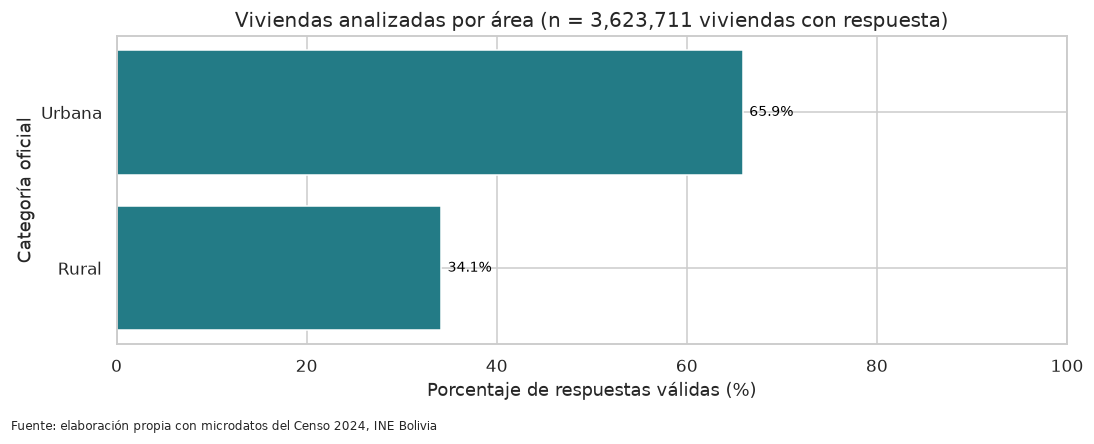

Predomina **Urbana**: 2,386,919 viviendas (65.87%). La variable permitirá comparar desigualdad de servicios.

In [14]:
tabla_area, n_area = frecuencias("urbrur")
display(tabla_area.rename(columns={"Categoría oficial":"Área","Viviendas":"Número de viviendas","% de respuestas":"Porcentaje"})[["Área","Número de viviendas","Porcentaje"]])
grafico_frecuencias(tabla_area, "Viviendas analizadas por área", n_area)
r = tabla_area.sort_values("Viviendas", ascending=False).iloc[0]
display(Markdown(f"Predomina **{r['Categoría oficial']}**: {r['Viviendas']:,} viviendas ({r['% de respuestas']:.2f}%). La variable permitirá comparar desigualdad de servicios."))

La comparación se limita a la población analítica, no a todos los registros del CSV.

### 6.2 Acceso al agua

Describimos procedencia y distribución por separado. La tubería no prueba potabilidad. Las categorías proceden del diccionario.

,Código,Categoría oficial,Viviendas,% de respuestas,% población analítica
0,1,Cañería de red,2579821,71.19,71.19
1,2,Pileta pública,280863,7.75,7.75
2,4,Pozo excavado o perforado con bomba,165062,4.56,4.56
3,7,"Río, acequia o vertiente no protegida",151339,4.18,4.18
4,5,Pozo no protegido o sin bomba,132706,3.66,3.66
5,3,Cosecha de agua de lluvia,94887,2.62,2.62
6,8,Carro repartidor (aguatero),86258,2.38,2.38
7,6,Manantial o vertiente protegida,74743,2.06,2.06
8,9,Otro,58032,1.60,1.60


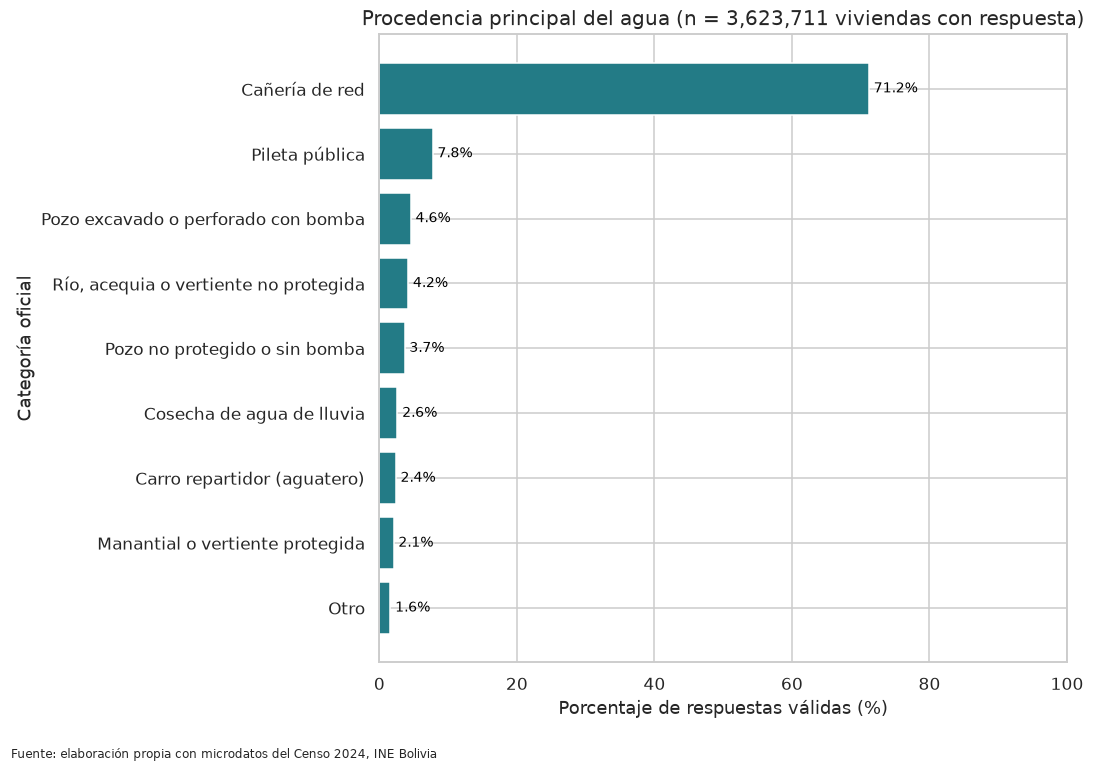

,Código,Categoría oficial,Viviendas,% de respuestas,% población analítica
0,1,Por cañería dentro de la vivienda,2123949,58.61,58.61
1,3,No se distribuye por cañería,802247,22.14,22.14
2,2,"Por cañería fuera de la vivienda, pero dentro ...",697515,19.25,19.25


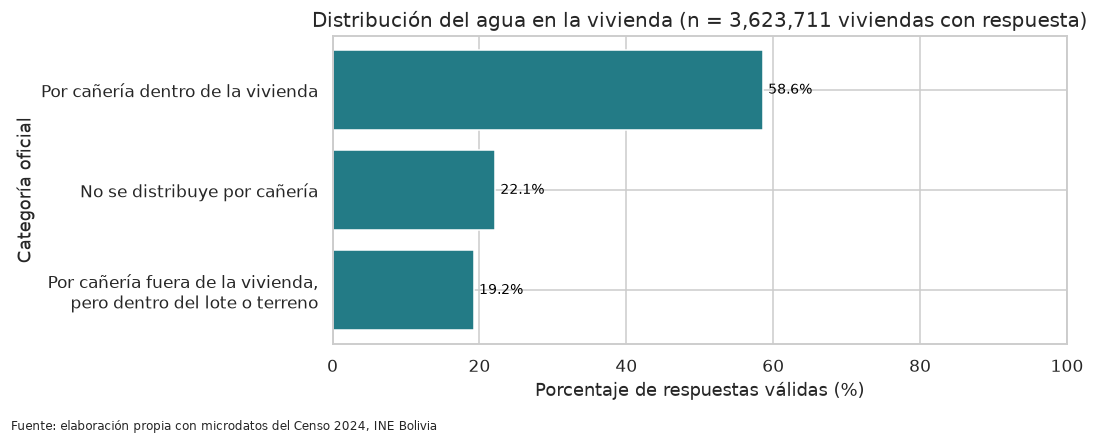

Predomina la procedencia **Cañería de red** (2,579,821; 71.19%). La distribución más común es **Por cañería dentro de la vivienda** (2,123,949; 58.61%).

In [15]:
tabla_agua_fuente, n_agua_fuente = frecuencias("v07_aguapro")
display(tabla_agua_fuente)
grafico_frecuencias(tabla_agua_fuente, "Procedencia principal del agua", n_agua_fuente)
tabla_agua_dist, n_agua_dist = frecuencias("v08_aguadist")
display(tabla_agua_dist)
grafico_frecuencias(tabla_agua_dist, "Distribución del agua en la vivienda", n_agua_dist)
a = tabla_agua_fuente.sort_values("Viviendas",ascending=False).iloc[0]
d = tabla_agua_dist.sort_values("Viviendas",ascending=False).iloc[0]
display(Markdown(f"Predomina la procedencia **{a['Categoría oficial']}** ({a['Viviendas']:,}; {a['% de respuestas']:.2f}%). La distribución más común es **{d['Categoría oficial']}** ({d['Viviendas']:,}; {d['% de respuestas']:.2f}%)."))

Los vacíos se informan aparte. Ninguna categoría por sí sola certifica calidad del agua.

### 6.3 Saneamiento

La pregunta de desagüe depende de la existencia de baño. Un desagüe vacío cuando no hay baño corresponde al salto del cuestionario.

,Código,Categoría oficial,Viviendas,% de respuestas,% población analítica
0,1,"Sí, usado solo por su hogar",2390728,65.97,65.97
1,3,No tiene,734257,20.26,20.26
2,2,"Sí, compartido con otros hogares",498726,13.76,13.76


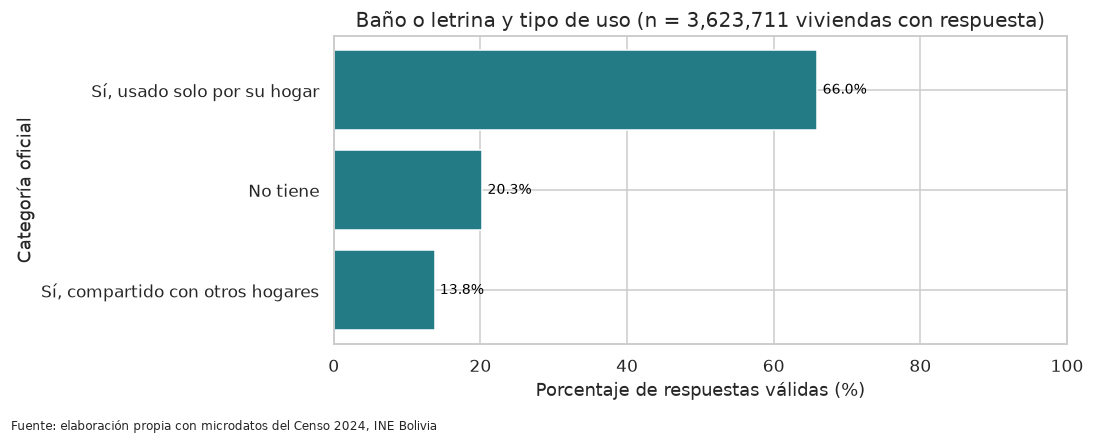

,Código,Categoría oficial,Viviendas,% de respuestas,% población analítica
0,1,A la red de alcantarillado,1734394,60.02,47.86
1,3,A un pozo ciego,769662,26.64,21.24
2,—,No aplica / vacío,734257,NaN,20.26
3,2,A una cámara séptica,292945,10.14,8.08
4,4,A un pozo de absorción,37978,1.31,1.05
5,6,Es baño ecológico,35405,1.23,0.98
6,5,"A la superficie (calle, quebrada o río)",19070,0.66,0.53


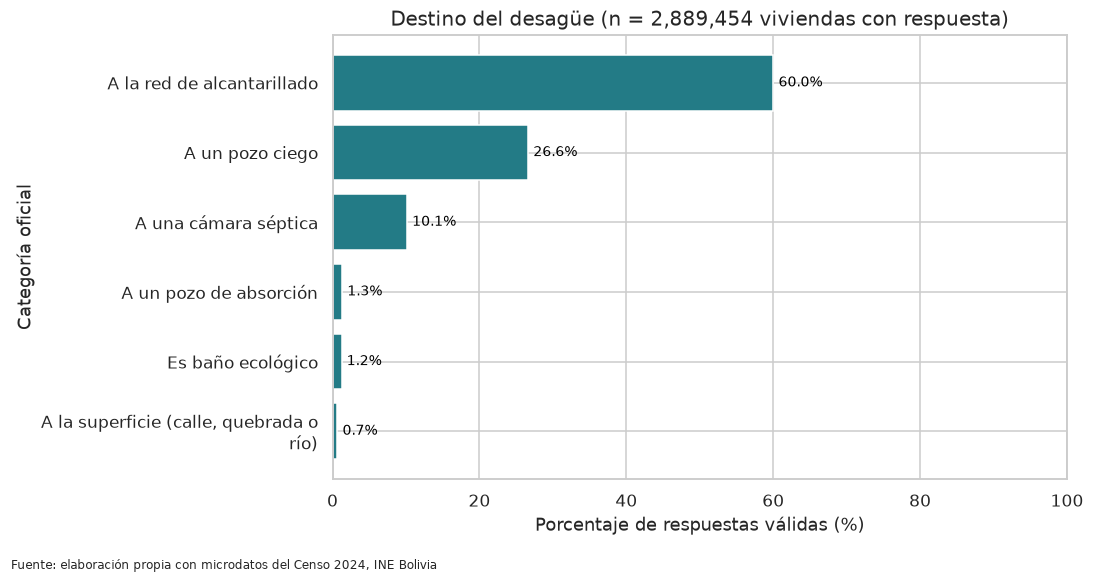

Viviendas sin baño: 734257
Vacíos de desagüe entre ellas: 734257
Respuestas válidas de desagüe: 2889454


La categoría **No tiene** representa 734,257 viviendas (20.26% del grupo analítico). En todas ellas, desagüe queda vacío por el salto del cuestionario.

In [16]:
tabla_bano, n_bano = frecuencias("v15_servsan")
display(tabla_bano)
grafico_frecuencias(tabla_bano, "Baño o letrina y tipo de uso", n_bano)
tabla_desague, n_desague = frecuencias("v16_desague")
display(tabla_desague)
grafico_frecuencias(tabla_desague, "Destino del desagüe", n_desague)
sin_bano = df_analisis["v15_servsan"].astype("string") == "3"
print("Viviendas sin baño:",int(sin_bano.sum()))
print("Vacíos de desagüe entre ellas:",int((sin_bano & df_analisis["v16_desague"].isna()).sum()))
print("Respuestas válidas de desagüe:",n_desague)
display(Markdown(f"La categoría **{codigos('v15_servsan')['3']}** representa {int(sin_bano.sum()):,} viviendas ({100*sin_bano.mean():.2f}% del grupo analítico). En todas ellas, desagüe queda vacío por el salto del cuestionario."))

La tabla de desagüe usa como denominador las viviendas que respondieron esa pregunta; la ausencia de baño se mide con la pregunta anterior.

### 6.4 Energía eléctrica

Comparamos las fuentes declaradas de energía. La categoría oficial No tiene identifica la ausencia explícita.

,Código,Categoría oficial,Viviendas,% de respuestas,% población analítica
0,1,Servicio público de energía eléctrica,3130729,86.40,86.40
1,5,No tiene,381134,10.52,10.52
2,3,Panel solar,60548,1.67,1.67
3,2,Motor propio (Generador),28409,0.78,0.78
4,4,Otro,22891,0.63,0.63


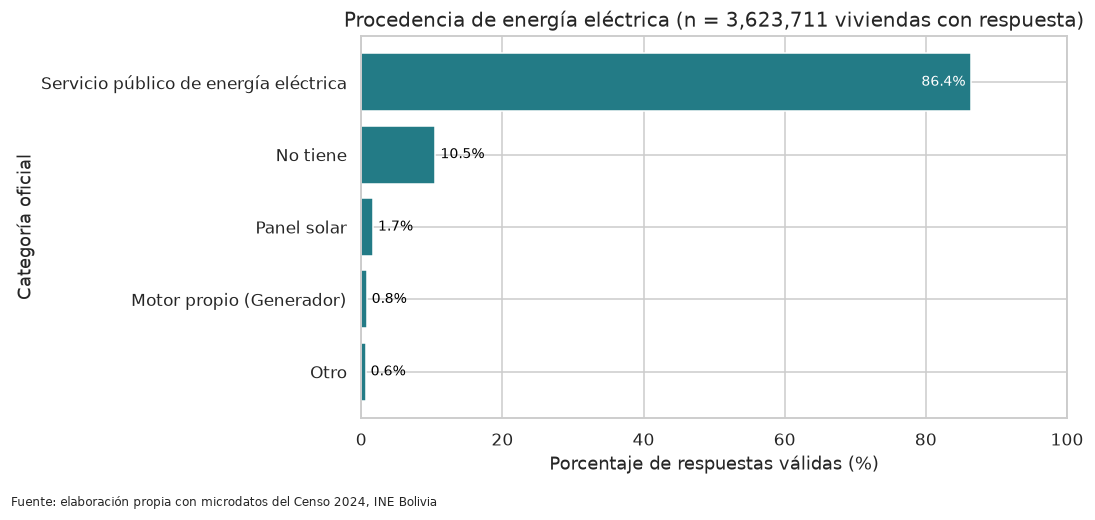

**No tiene** corresponde a 381,134 viviendas (10.52% de respuestas válidas).

In [17]:
tabla_electricidad, n_electricidad = frecuencias("v09_energia")
display(tabla_electricidad)
grafico_frecuencias(tabla_electricidad, "Procedencia de energía eléctrica", n_electricidad)
r = tabla_electricidad.loc[tabla_electricidad["Código"]=="5"].iloc[0]
display(Markdown(f"**{codigos('v09_energia')['5']}** corresponde a {r['Viviendas']:,} viviendas ({r['% de respuestas']:.2f}% de respuestas válidas)."))

La fuente declarada no informa continuidad ni seguridad del suministro.

### 6.5 Acceso a internet

El diccionario describe internet fijo, móvil y una variable combinada de fijo o móvil. Comprobamos su concordancia cuando las respuestas originales lo permiten.

Casos determinables: 3491434
Desacuerdos con la variable combinada: 0
v19e_inetfijo | vacíos: 0


,Código,Categoría oficial,Viviendas,% de respuestas,% población analítica
0,2,No,2155073,59.47,59.47
1,1,Sí,1336733,36.89,36.89
2,9,Sin especificar,131905,3.64,3.64


v19f_inetmovil | vacíos: 0


,Código,Categoría oficial,Viviendas,% de respuestas,% población analítica
0,1,Sí,2378040,65.62,65.62
1,2,No,1113607,30.73,30.73
2,9,Sin especificar,132064,3.64,3.64


v19e_f | vacíos: 0


,Código,Categoría oficial,Viviendas,% de respuestas,% población analítica
0,1,Sí,2663395,73.50,73.50
1,2,No,828624,22.87,22.87
2,9,Sin especificar,131692,3.63,3.63


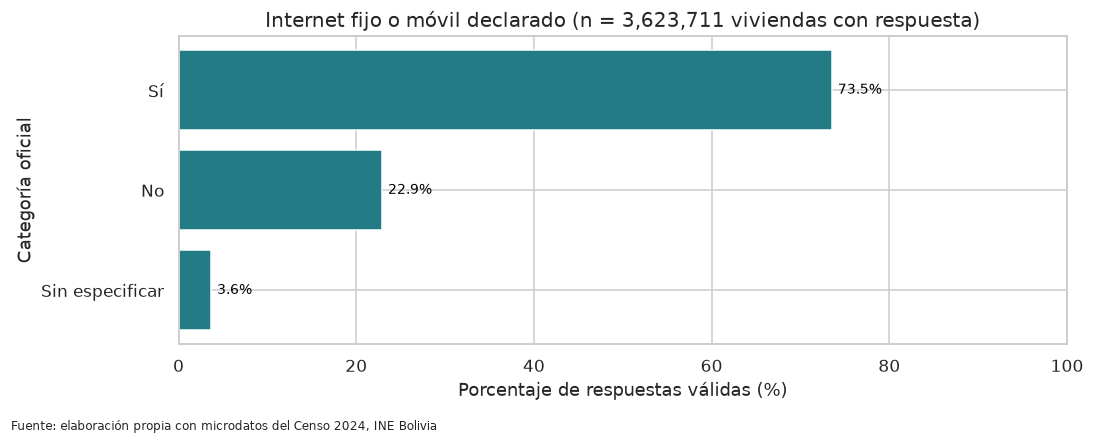

In [18]:
fijo = df_analisis["v19e_inetfijo"].astype("string")
movil = df_analisis["v19f_inetmovil"].astype("string")
combinado = df_analisis["v19e_f"].astype("string")
esperado = pd.Series(pd.NA,index=df_analisis.index,dtype="string")
esperado.loc[(fijo=="1")|(movil=="1")] = "1"
esperado.loc[(fijo=="2")&(movil=="2")] = "2"
determinable = esperado.notna()
print("Casos determinables:",int(determinable.sum()))
print("Desacuerdos con la variable combinada:",int((combinado.loc[determinable]!=esperado.loc[determinable]).fillna(True).sum()))
for col in ["v19e_inetfijo","v19f_inetmovil","v19e_f"]:
    t,n = frecuencias(col)
    print(col,"| vacíos:",len(df_analisis)-n)
    display(t)
tabla_internet,n_internet = frecuencias("v19e_f")
grafico_frecuencias(tabla_internet,"Internet fijo o móvil declarado",n_internet)
del fijo,movil,combinado,esperado,determinable

La variable combinada documentada representa acceso general; el código 9 = Sin especificar y los vacíos quedan fuera del denominador válido.

### 6.6 Características de la vivienda

Seleccionamos paredes, piso, combustible de cocina, eliminación de basura y tipología del hogar por su posible relación descriptiva con precariedad.

v03_pared 3. Cual es el material de construcción más utilizado en las paredes de esta vivienda n= 3623711


,Código,Categoría oficial,Viviendas,% de respuestas,% población analítica
0,1,"Ladrillo, bloque de cemento, hormigón",2461530,67.93,67.93
1,2,"Adobe, tapial",850773,23.48,23.48
2,5,Madera,203109,5.60,5.60
3,7,Otro,43189,1.19,1.19
4,4,Piedra,28738,0.79,0.79
5,3,"Tabique, quinche",19202,0.53,0.53
6,6,"Caña, palma, tronco",17170,0.47,0.47


v06_piso 6. Cuál es el material más utilizado en los pisos de esta vivienda n= 3623711


,Código,Categoría oficial,Viviendas,% de respuestas,% población analítica
0,5,Cemento,1322225,36.49,36.49
1,4,"Cerámica, porcelanato",1014353,27.99,27.99
2,1,Tierra,800688,22.10,22.10
3,3,"Machimbre, parquet",204990,5.66,5.66
4,7,Ladrillo,92234,2.55,2.55
5,2,Tablón de madera,78967,2.18,2.18
6,6,"Mosaico, baldosa",51556,1.42,1.42
7,8,Piso Flotante,35181,0.97,0.97
8,9,Otro,23517,0.65,0.65


v10_combus 10. Cuál es el principal combustible o energía que utiliza para cocinar n= 3623711


,Código,Categoría oficial,Viviendas,% de respuestas,% población analítica
0,1,Gas en garrafa,1983377,54.73,54.73
1,2,Gas por cañería (a domicilio),911065,25.14,25.14
2,3,Leña,629156,17.36,17.36
3,8,No cocina,57706,1.59,1.59
4,4,"Guano, bosta o taquia",25568,0.71,0.71
5,5,Electricidad,13447,0.37,0.37
6,7,Otro,2808,0.08,0.08
7,6,Energía solar (cocina solar),584,0.02,0.02


v11_basura 11. Habitualmente. Qué hacen con la basura que generan n= 3623711


,Código,Categoría oficial,Viviendas,% de respuestas,% población analítica
0,2,La entregan al carro basurero (servicio público),1647912,45.48,45.48
1,5,La queman,999714,27.59,27.59
2,1,La depositan en el contenedor o basurero público,673955,18.60,18.60
3,6,La entierran,124764,3.44,3.44
4,3,La botan en un terreno baldío o la calle,82228,2.27,2.27
5,4,La botan al río,61551,1.70,1.70
6,7,Otra forma,33587,0.93,0.93


tip_hog Tipología de hogar n= 3623711


,Código,Categoría oficial,Viviendas,% de respuestas,% población analítica
0,1,Hogar unipersonal,937816,25.88,25.88
1,4,Hogar nuclear completo,886438,24.46,24.46
2,5,Hogar extendido,835245,23.05,23.05
3,3,Hogar monoparental,622660,17.18,17.18
4,2,Hogar de pareja nuclear,242348,6.69,6.69
5,6,Hogar compuesto,90337,2.49,2.49
6,7,Otro tipo de hogar,4882,0.13,0.13
7,8,Hogar de menores sin jefe de hogar,3985,0.11,0.11


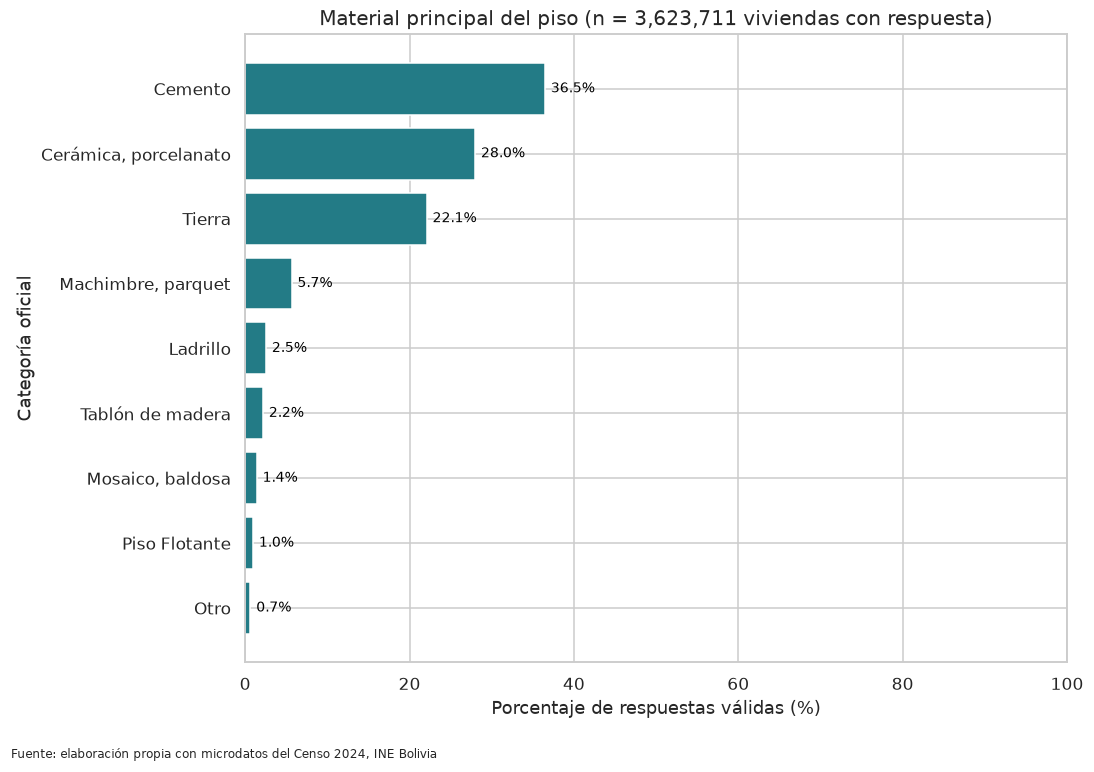

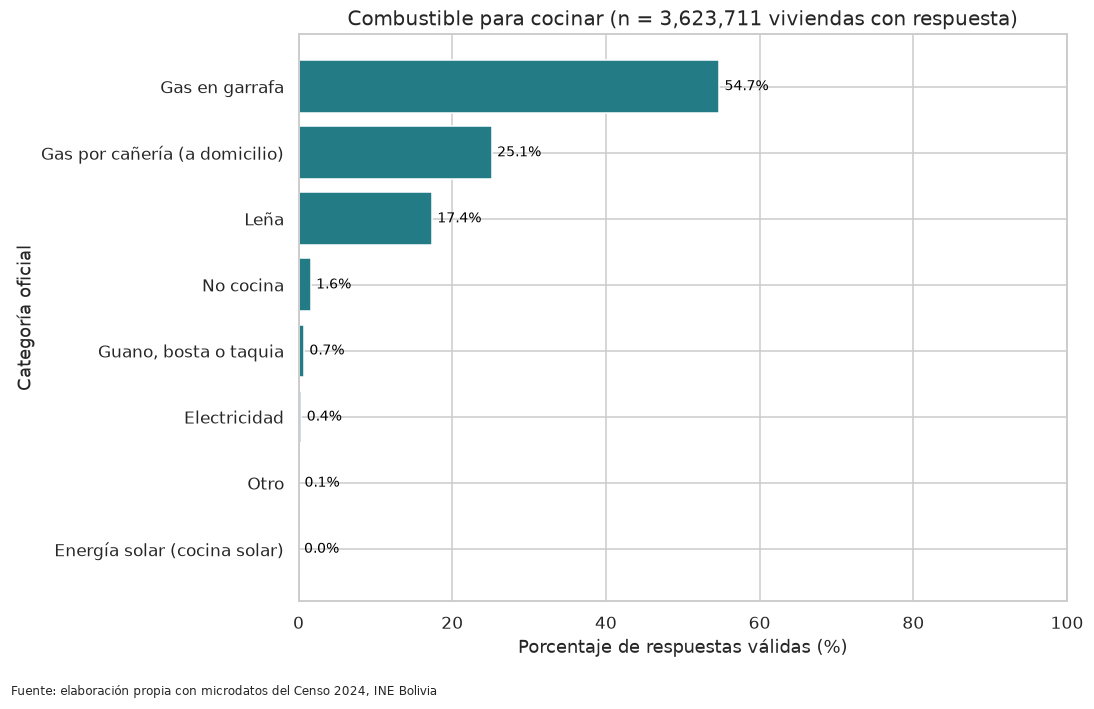

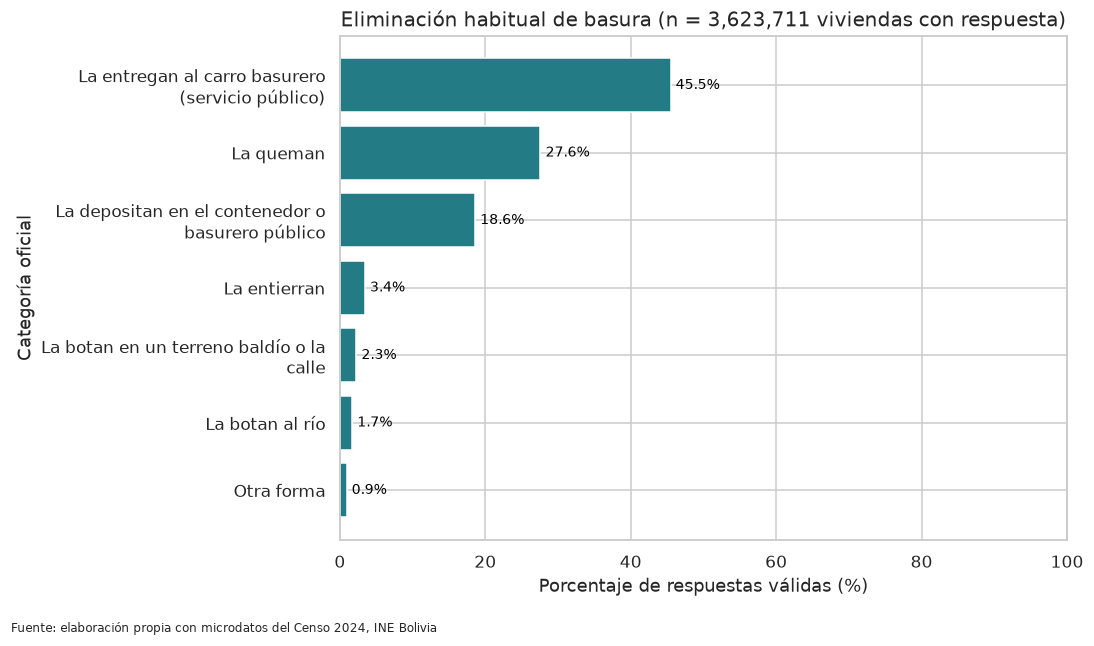

**Categorías predominantes:** v03_pared: Ladrillo, bloque de cemento, hormigón (67.93% de 3,623,711 respuestas); v06_piso: Cemento (36.49% de 3,623,711 respuestas); v10_combus: Gas en garrafa (54.73% de 3,623,711 respuestas); v11_basura: La entregan al carro basurero (servicio público) (45.48% de 3,623,711 respuestas); tip_hog: Hogar unipersonal (25.88% de 3,623,711 respuestas). Son distribuciones descriptivas, no efectos causales.

In [19]:
complementarias_elegidas = ["v03_pared","v06_piso","v10_combus","v11_basura","tip_hog"]
for col in complementarias_elegidas:
    t,n = frecuencias(col)
    print(col,dic_por_columna[col]["descripcion_oficial"],"n=",n)
    display(t)
for col,titulo in [("v06_piso","Material principal del piso"),("v10_combus","Combustible para cocinar"),("v11_basura","Eliminación habitual de basura")]:
    t,n = frecuencias(col)
    grafico_frecuencias(t,titulo,n)
principales = []
for col in complementarias_elegidas:
    t,n = frecuencias(col)
    r = t.sort_values("Viviendas",ascending=False).iloc[0]
    principales.append(f"{col}: {r['Categoría oficial']} ({r['% de respuestas']:.2f}% de {n:,} respuestas)")
display(Markdown("**Categorías predominantes:** " + "; ".join(principales) + ". Son distribuciones descriptivas, no efectos causales."))

Estas variables pueden acompañar el estudio de carencias, pero las distribuciones no demuestran relaciones causales ni deciden predictores.

## 7. Análisis bivariado

Comparamos las carencias operacionales calculadas antes para mantener el orden de ejecución. Cada porcentaje usa viviendas clasificables en esa dimensión dentro del grupo; diferencias territoriales no implican causalidad.

In [20]:
nombres_dim = {"carencia_agua":"Agua","carencia_saneamiento":"Saneamiento","carencia_electricidad":"Electricidad","carencia_internet":"Internet"}
def resumen_territorial(base,grupo):
    g = base.groupby(grupo,observed=True,dropna=False)
    tabla = g.size().rename("N_analisis").to_frame()
    for c in indicadores:
        nombre = nombres_dim[c]
        tabla[f"N_valida_{nombre}"] = g[c].count()
        tabla[f"%_carencia_{nombre}"] = (g[c].mean()*100).round(2)
    return tabla.reset_index()
df_analisis["clave_municipal"] = (df_analisis["idep"].astype("string")+
                                   df_analisis["iprov"].astype("string")+
                                   df_analisis["imun"].astype("string")).astype("category")
print("Valores aislados de imun:",df_analisis["imun"].nunique())
print("Claves compuestas idep+iprov+imun:",df_analisis["clave_municipal"].nunique())
print("Longitud observada:",df_analisis["clave_municipal"].astype("string").str.len().dropna().unique().tolist())

Valores aislados de imun: 8
Claves compuestas idep+iprov+imun: 343
Longitud observada: [6]


La clave de seis caracteres conserva departamento, provincia y municipio local. El archivo no documenta nombres oficiales para esas claves; se muestran sin inventarlos.

### 7.1 Servicios básicos según área urbana/rural

Calculamos N válido y porcentaje de carencia por dimensión para Urbana y Rural, y comparamos con barras agrupadas.

,N_analisis,N_valida_Agua,%_carencia_Agua,N_valida_Saneamiento,%_carencia_Saneamiento,N_valida_Electricidad,%_carencia_Electricidad,N_valida_Internet,%_carencia_Internet,Área
0,2386919,2265415,1.29,2075291,27.31,2386919,2.32,2312075,12.29,Urbana
1,1236792,1119119,22.77,856444,79.53,1236792,26.34,1179944,46.14,Rural


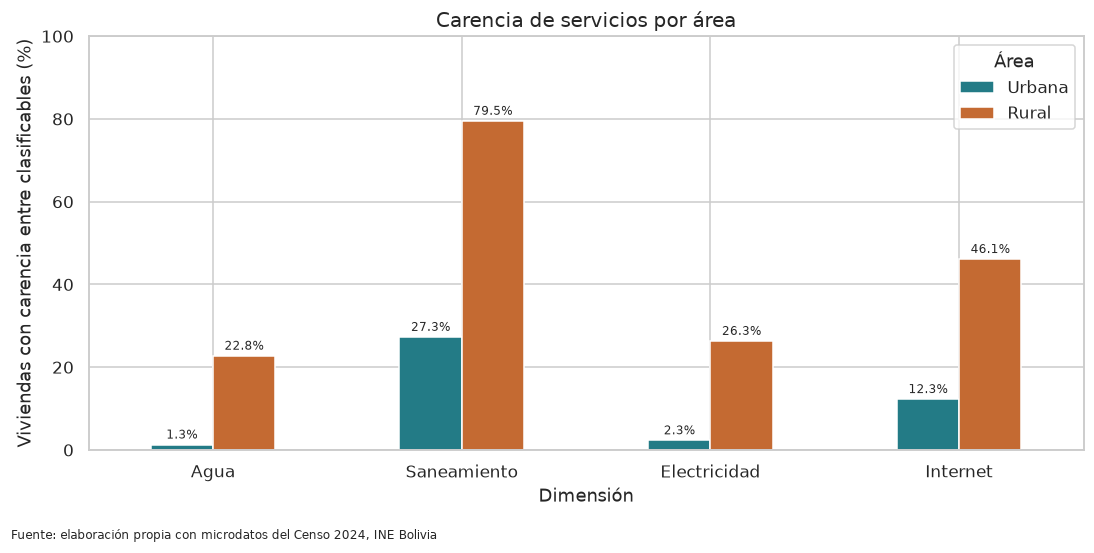

Mayor brecha absoluta: **Saneamiento**, +52.22 puntos (rural menos urbana). Menor brecha: **Agua**, +21.48 puntos.

In [21]:
tabla_area_servicios = resumen_territorial(df_analisis,"urbrur")
tabla_area_servicios["Área"] = tabla_area_servicios["urbrur"].astype("string").map(codigos("urbrur"))
display(tabla_area_servicios.drop(columns="urbrur"))
tasas = tabla_area_servicios.set_index("Área")[[f"%_carencia_{n}" for n in nombres_dim.values()]].T
tasas.index = list(nombres_dim.values())
ax = tasas.plot.bar(rot=0,figsize=(10,5),color=["#237b86","#c46a32"])
ax.set(title="Carencia de servicios por área",xlabel="Dimensión",ylabel="Viviendas con carencia entre clasificables (%)",ylim=(0,100))
for cont in ax.containers: ax.bar_label(cont,fmt="%.1f%%",padding=2,fontsize=8)
ax.legend(title="Área")
ax.figure.text(0.01,0.01,FUENTE,fontsize=8)
ax.figure.tight_layout(rect=(0,0.04,1,1))
plt.show()
tasas_area = tabla_area_servicios.set_index("Área")
brechas = (tasas_area.loc["Rural",[f"%_carencia_{n}" for n in nombres_dim.values()]] -
           tasas_area.loc["Urbana",[f"%_carencia_{n}" for n in nombres_dim.values()]]).astype(float)
mayor = brechas.abs().idxmax().replace("%_carencia_","")
menor = brechas.abs().idxmin().replace("%_carencia_","")
display(Markdown(f"Mayor brecha absoluta: **{mayor}**, {brechas[f'%_carencia_{mayor}']:+.2f} puntos (rural menos urbana). Menor brecha: **{menor}**, {brechas[f'%_carencia_{menor}']:+.2f} puntos."))

Los denominadores válidos cambian entre servicios. Las brechas observadas no prueban que el área cause las carencias.

### 7.2 Servicios básicos por departamento

idep tiene nueve códigos de dos caracteres, pero los archivos no incluyen equivalencias oficiales con nombres departamentales. Conservamos los códigos y reportamos N válido por dimensión.

,idep,N_analisis,N_valida_Agua,%_carencia_Agua,N_valida_Saneamiento,%_carencia_Saneamiento,N_valida_Electricidad,%_carencia_Electricidad,N_valida_Internet,%_carencia_Internet
0,01,184969,175493,10.11,163476,49.23,184969,13.38,177922,24.52
1,02,1069838,1005519,8.68,902913,41.1,1069838,11.09,1039341,27.99
2,03,675064,587514,10.03,532909,40.06,675064,12.89,654331,21.01
3,04,190973,180061,11.14,175855,51.04,190973,12.97,185618,24.35
4,05,303745,286339,14.28,272997,65.79,303745,18.62,291105,32.83
5,06,160254,154710,2.4,119985,34.95,160254,3.99,155343,16.43
6,07,877257,853227,2.28,657522,35.75,877257,4.65,836363,17.55
7,08,126668,109146,24.58,85452,34.25,126668,13.51,118782,28.96
8,09,34943,32525,27.82,20626,34.87,34943,14.9,33214,27.44


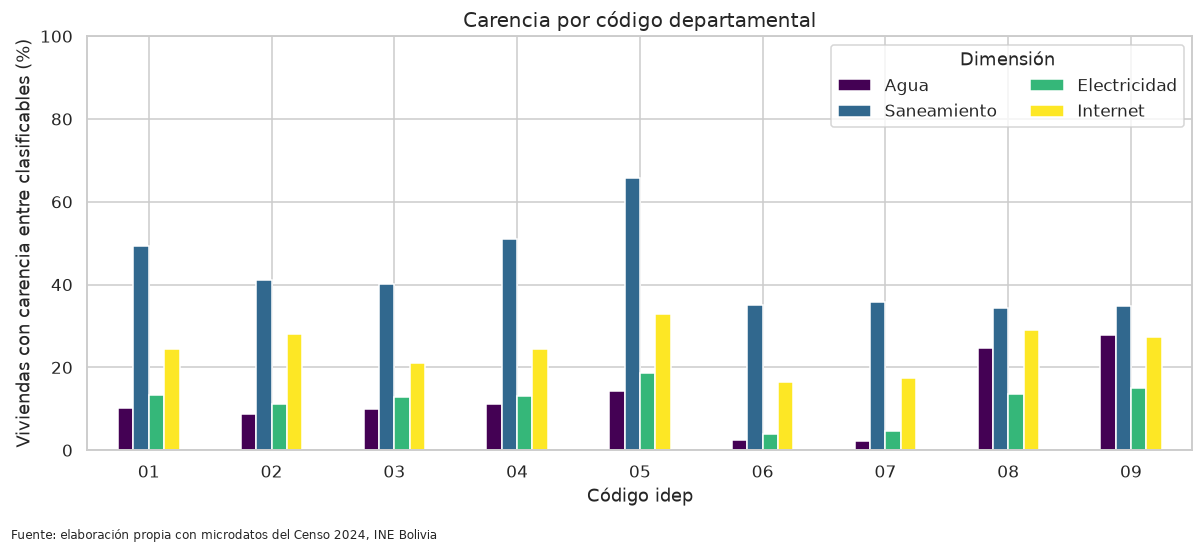

En agua, el código 09 presenta 27.82% entre 32,525 viviendas válidas, frente a 2.28% entre 853,227 del código 07.

In [22]:
tabla_departamento = resumen_territorial(df_analisis,"idep").sort_values("idep")
display(tabla_departamento)
t = tabla_departamento.set_index("idep")[[f"%_carencia_{n}" for n in nombres_dim.values()]]
t.columns = list(nombres_dim.values())
ax = t.plot.bar(figsize=(11,5),rot=0,colormap="viridis")
ax.set(title="Carencia por código departamental",xlabel="Código idep",ylabel="Viviendas con carencia entre clasificables (%)",ylim=(0,100))
ax.legend(title="Dimensión",ncol=2)
ax.figure.text(0.01,0.01,FUENTE,fontsize=8)
ax.figure.tight_layout(rect=(0,0.04,1,1))
plt.show()
dim = "%_carencia_Agua"
max_dep = tabla_departamento.loc[tabla_departamento[dim].astype(float).idxmax()]
min_dep = tabla_departamento.loc[tabla_departamento[dim].astype(float).idxmin()]
display(Markdown(f"En agua, el código {max_dep['idep']} presenta {max_dep[dim]:.2f}% entre {int(max_dep['N_valida_Agua']):,} viviendas válidas, frente a {min_dep[dim]:.2f}% entre {int(min_dep['N_valida_Agua']):,} del código {min_dep['idep']}."))

Las tasas describen heterogeneidad entre códigos. No se asignan nombres de departamento sin una tabla oficial de correspondencia.

### 7.3 Servicios básicos por municipio

imun se repite en distintas provincias y departamentos. Agrupamos por la clave compuesta idep+iprov+imun, conservando sus ceros iniciales.

In [23]:
tabla_municipio = resumen_territorial(df_analisis,"clave_municipal")
print("Claves territoriales compuestas:",len(tabla_municipio))
print("Rango de N analítico:",int(tabla_municipio["N_analisis"].min()),"a",int(tabla_municipio["N_analisis"].max()))
display(tabla_municipio.sort_values("N_analisis",ascending=False).head(15))

Claves territoriales compuestas: 343
Rango de N analítico: 173 a 453158


,clave_municipal,N_analisis,N_valida_Agua,%_carencia_Agua,N_valida_Saneamiento,%_carencia_Saneamiento,N_valida_Electricidad,%_carencia_Electricidad,N_valida_Internet,%_carencia_Internet
252,070101,453158,451213,0.1,400586,29.49,453158,0.36,433402,8.8
33,020105,297898,289675,0.6,279899,20.77,297898,2.83,292198,14.24
29,020101,250931,246226,0.85,248765,16.97,250931,1.2,246907,8.7
116,030101,212273,166100,0.58,183911,23.3,212273,2.18,207253,9.69
164,040101,96123,93492,0.64,90274,27.93,96123,2.48,94417,11.19
0,010101,92531,88084,2.17,89174,32.05,92531,3.42,89929,10.76
241,060101,72709,71310,0.74,60624,32.64,72709,1.83,70753,10.58
142,031001,69313,58631,2.43,58404,28.03,69313,6.52,67527,14.06
199,050101,67379,65024,2.78,66299,38.31,67379,4.7,65773,11.43
137,030901,49171,47400,1.86,41309,24.11,49171,2.19,47964,12.5


La tabla contiene las tasas por clave y sus denominadores. La sección 9 mostrará el Top 10 por IPS con N válido; faltan nombres oficiales de municipios.

## 8. Construcción de indicadores de carencia

Las reglas siguientes son definiciones operacionales de este proyecto, no indicadores oficiales del INE. Cada indicador usa 1 = carencia, 0 = ausencia de carencia según la regla, y NA = información insuficiente. El cálculo se colocó antes de los cruces para ejecutar el notebook linealmente.

### 8.1 Carencia de agua

Fuente: v07_aguapro. Valor 0 para 1 cañería de red, 2 pileta pública, 4 pozo con bomba y 6 vertiente protegida. Valor 1 para 5 pozo no protegido o sin bomba y 7 río, acequia o vertiente no protegida. Valores 3 agua de lluvia, 8 carro repartidor y 9 otro quedan NA porque la categoría no informa protección. v08_aguadist describe distribución, no la fuente. La regla aproxima protección de fuente; no mide potabilidad.

In [24]:
display(tabla_servicios.loc[tabla_servicios["dimension"]=="Agua",["variable_real","descripcion_oficial","significado_de_codigos"]])

,variable_real,descripcion_oficial,significado_de_codigos
0,v07_aguapro,"7. Principalmente, el agua que usan en la vivi...","{'1': 'Cañería de red', '2': 'Pileta pública',..."
1,v08_aguadist,8. El agua que usan en la vivienda se distribuye:,"{'1': 'Por cañería dentro de la vivienda', '2'..."


Los vacíos no aplicables fueron excluidos del denominador analítico; las fuentes de protección no comprobable quedan sin clasificación.

### 8.2 Carencia de saneamiento

Valor 0 para baño de uso exclusivo (v15=1) con alcantarillado, cámara séptica o baño ecológico (v16=1,2,6). Valor 1 para ausencia de baño (v15=3), baño compartido (v15=2) o descarga a superficie (v16=5). Baño exclusivo con pozo ciego o de absorción (v16=3,4) queda NA porque el archivo no documenta contención. Cuando no hay baño, el desagüe vacío es el salto correcto y no impide clasificar la carencia.

In [25]:
display(tabla_servicios.loc[tabla_servicios["dimension"]=="Saneamiento",["variable_real","descripcion_oficial","significado_de_codigos"]])

,variable_real,descripcion_oficial,significado_de_codigos
2,v15_servsan,"15. Tienen, baño o letrina","{'1': 'Sí, usado solo por su hogar', '2': 'Sí,..."
3,v16_desague,16. El baño o letrina tiene desagüe:,"{'1': 'A la red de alcantarillado', '2': 'A un..."


La regla prioriza privacidad y destino documentado; no certifica tratamiento efectivo de aguas residuales.

### 8.3 Carencia de electricidad

v09_energia: valor 0 para códigos 1–4, que declaran alguna fuente de energía eléctrica; valor 1 para código 5, No tiene. Una respuesta vacía sería NA. La regla no mide continuidad del suministro.

In [26]:
display(tabla_servicios.loc[tabla_servicios["dimension"]=="Electricidad",["variable_real","descripcion_oficial","significado_de_codigos"]])

,variable_real,descripcion_oficial,significado_de_codigos
4,v09_energia,9. De donde proviene la energía eléctrica que ...,"{'1': 'Servicio público de energía eléctrica',..."


El código Otro conserva una fuente declarada aunque su tipo específico sea desconocido.

### 8.4 Carencia de internet

v19e_f está descrita oficialmente como internet fijo o móvil. Valor 0 para 1 Sí, 1 para 2 No y NA para 9 Sin especificar o vacío. La pregunta original habla de su hogar; el resultado se asigna al registro de vivienda sin asumir que todas sus personas usan internet.

In [27]:
display(tabla_servicios.loc[tabla_servicios["dimension"]=="Internet",["variable_real","descripcion_oficial","significado_de_codigos"]])
resumen_indicadores = pd.DataFrame([
    {"Indicador":nombres_dim[c],"Con acceso":int((df_analisis[c]==0).sum()),
     "Con carencia":int((df_analisis[c]==1).sum()),"No clasificable":int(df_analisis[c].isna().sum()),
     "Total aplicable":len(df_analisis),"N válido":int(df_analisis[c].notna().sum()),
     "% carencia":round(100*(df_analisis[c]==1).sum()/df_analisis[c].notna().sum(),2)}
    for c in indicadores])
display(resumen_indicadores)
assert (resumen_indicadores[["Con acceso","Con carencia","No clasificable"]].sum(axis=1)==resumen_indicadores["Total aplicable"]).all()
assert all(set(df_analisis[c].dropna().unique()).issubset({0,1}) for c in indicadores)
assert df_analisis.loc[df_analisis["v19e_f"].astype("string")=="9","carencia_internet"].isna().all()
assert df_analisis.loc[df_analisis["v07_aguapro"].astype("string").isin({"3","8","9"}),"carencia_agua"].isna().all()
assert df_analisis.loc[(df_analisis["v15_servsan"].astype("string")=="1") & df_analisis["v16_desague"].astype("string").isin({"3","4"}),"carencia_saneamiento"].isna().all()
print("Validaciones de códigos, dominio y sumas: correctas.")

,variable_real,descripcion_oficial,significado_de_codigos
5,v19e_inetfijo,19.5. Su hogar tiene: Internet fijo en la vivi...,"{'1': 'Sí', '2': 'No', '9': 'Sin especificar'}"
6,v19f_inetmovil,19.6. Su hogar tiene: Internet móvil (megas o ...,"{'1': 'Sí', '2': 'No', '9': 'Sin especificar'}"
7,v19e_f,Internet fijo en la vivienda o internet móvil,"{'1': 'Sí', '2': 'No', '9': 'Sin especificar'}"


,Indicador,Con acceso,Con carencia,No clasificable,Total aplicable,N válido,% carencia
0,Agua,3100489,284045,239177,3623711,3384534,8.39
1,Saneamiento,1683914,1247821,691976,3623711,2931735,42.56
2,Electricidad,3242577,381134,0,3623711,3623711,10.52
3,Internet,2663395,828624,131692,3623711,3492019,23.73


Validaciones de códigos, dominio y sumas: correctas.


El porcentaje de cada dimensión divide por N válido, no por Total aplicable. Los casos no clasificables quedan visibles y no se convierten en acceso.

## 9. Índice de Precariedad de Servicios (IPS)

El IPS se calcula a nivel vivienda únicamente cuando las cuatro carencias son clasificables. n_carencias suma 0–4. vivienda_precaria vale 1 con dos o más carencias y 0 con menos de dos. El IPS es el porcentaje de viviendas válidas con valor 1. Esta definición y su umbral son construcciones del proyecto, no un indicador oficial del INE.

Población analítica: 3623711
Viviendas válidas para IPS: 2635157
Excluidas por dimensión no clasificable: 988554
Cobertura: 72.72 %
IPS nacional del proyecto: 19.6 %


,Viviendas,Porcentaje
Número de carencias,,
0,1377478,52.27
1,741185,28.13
2,302390,11.48
3,145921,5.54
4,68183,2.59


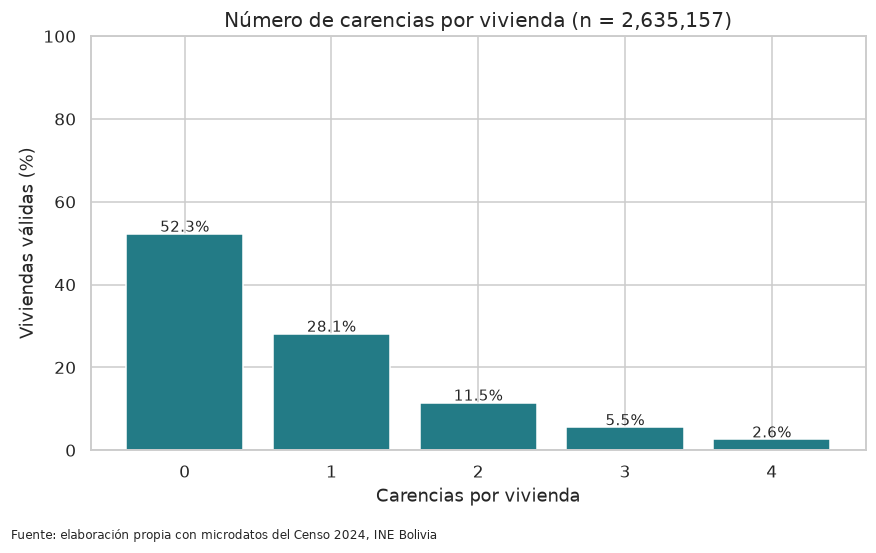

In [28]:
completa = df_analisis[indicadores].notna().all(axis=1)
df_ips = df_analisis.loc[completa,["idep","iprov","imun","clave_municipal","urbrur"]+indicadores].copy()
df_ips["n_carencias"] = df_ips[indicadores].sum(axis=1).astype("int8")
df_ips["vivienda_precaria"] = (df_ips["n_carencias"]>=2).astype("int8")
N_ips = len(df_ips)
N_excluido_ips = len(df_analisis)-N_ips
IPS_nacional = 100*df_ips["vivienda_precaria"].mean()
print("Población analítica:",len(df_analisis))
print("Viviendas válidas para IPS:",N_ips)
print("Excluidas por dimensión no clasificable:",N_excluido_ips)
print("Cobertura:",round(100*N_ips/len(df_analisis),2),"%")
print("IPS nacional del proyecto:",round(IPS_nacional,2),"%")
assert df_ips["n_carencias"].between(0,4).all()
assert N_ips+N_excluido_ips==len(df_analisis)
tabla_carencias = df_ips["n_carencias"].value_counts().reindex(range(5),fill_value=0).sort_index().rename_axis("Número de carencias").to_frame("Viviendas")
tabla_carencias["Porcentaje"] = (100*tabla_carencias["Viviendas"]/N_ips).round(2)
display(tabla_carencias)
fig,ax = plt.subplots(figsize=(8,5))
ax.bar(tabla_carencias.index.astype(str),tabla_carencias["Porcentaje"],color="#237b86")
for x,p in enumerate(tabla_carencias["Porcentaje"]): ax.text(x,p+0.5,f"{p:.1f}%",ha="center")
ax.set(title=f"Número de carencias por vivienda (n = {N_ips:,})",xlabel="Carencias por vivienda",ylabel="Viviendas válidas (%)",ylim=(0,100))
fig.text(0.01,0.01,FUENTE,fontsize=8)
fig.tight_layout(rect=(0,0.04,1,1))
plt.show()

Las viviendas excluidas permanecen en df_analisis y no reciben un valor de IPS. La distribución representa solo a las viviendas válidas en las cuatro dimensiones.

Calculamos el IPS por área y claves territoriales. Cada tabla muestra N válido; las tasas extremas con pocos casos requieren cautela.

,Área,N_analisis,N_validas,Cobertura_%,N_precarias,IPS_%
0,Urbana,2386919,1916157,80.28,101706,5.31
1,Rural,1236792,719000,58.13,414788,57.69


,idep,N_validas,N_precarias,IPS_%
0,01,149146,35464,23.78
1,02,825886,176022,21.31
2,03,451436,89241,19.77
3,04,161294,40306,24.99
4,05,245879,92012,37.42
5,06,112394,10479,9.32
6,07,603881,54423,9.01
7,08,67092,14772,22.02
8,09,18149,3775,20.80


Claves territoriales compuestas con IPS: 343


,clave_municipal,N_validas,N_precarias,IPS_%
166,040103,1636,1561,95.42
333,090202,155,140,90.32
227,051003,386,337,87.31
47,020308,2185,1872,85.68
42,020303,2742,2313,84.35
111,021803,371,307,82.75
122,030303,4735,3896,82.28
155,031304,1896,1554,81.96
339,090402,224,181,80.80
154,031303,907,731,80.60


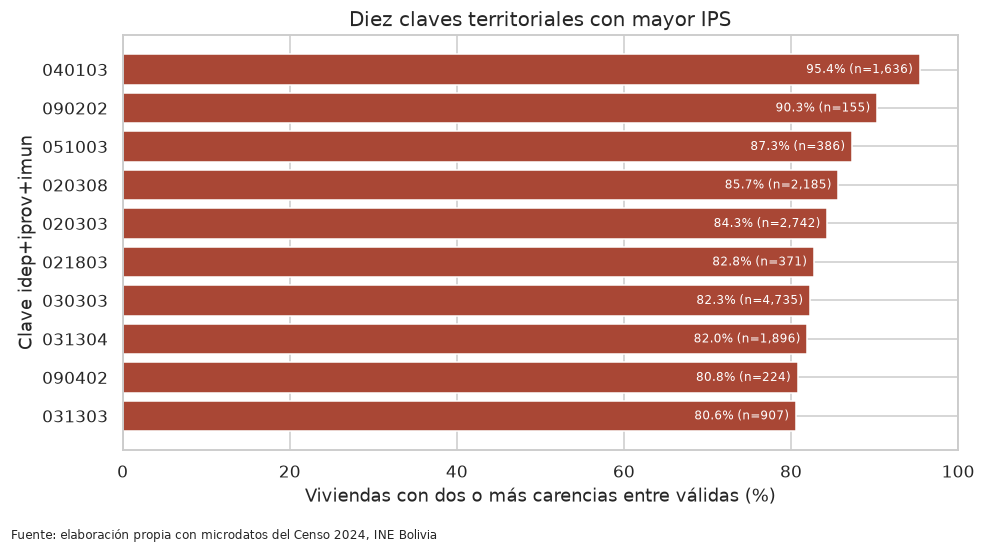

In [29]:
def tabla_ips(base,grupo):
    t = base.groupby(grupo,observed=True).agg(N_validas=("vivienda_precaria","size"),N_precarias=("vivienda_precaria","sum"))
    t["IPS_%"] = (100*t["N_precarias"]/t["N_validas"]).round(2)
    return t.reset_index()
ips_area = tabla_ips(df_ips,"urbrur")
ips_area["Área"] = ips_area["urbrur"].astype("string").map(codigos("urbrur"))
ips_area["N_analisis"] = ips_area["Área"].map(tabla_area_servicios.set_index("Área")["N_analisis"])
ips_area["Cobertura_%"] = (100*ips_area["N_validas"]/ips_area["N_analisis"]).round(2)
display(ips_area[["Área","N_analisis","N_validas","Cobertura_%","N_precarias","IPS_%"]])
ips_departamento = tabla_ips(df_ips,"idep").sort_values("idep")
display(ips_departamento)
ips_municipio = tabla_ips(df_ips,"clave_municipal").sort_values(["IPS_%","N_validas"],ascending=[False,False])
print("Claves territoriales compuestas con IPS:",len(ips_municipio))
display(ips_municipio.head(10))
t = ips_municipio.head(10).sort_values("IPS_%")
fig,ax = plt.subplots(figsize=(9,5))
ax.barh(t["clave_municipal"].astype(str),t["IPS_%"],color="#a94735")
for i,(_,r) in enumerate(t.iterrows()):
    ax.text(r["IPS_%"]-0.8,i,f"{r['IPS_%']:.1f}% (n={int(r['N_validas']):,})",va="center",ha="right",color="white",fontsize=8)
ax.set(title="Diez claves territoriales con mayor IPS",xlabel="Viviendas con dos o más carencias entre válidas (%)",ylabel="Clave idep+iprov+imun",xlim=(0,100))
fig.text(0.01,0.01,FUENTE,fontsize=8)
fig.tight_layout(rect=(0,0.04,1,1))
plt.show()

Los códigos carecen de nombres oficiales en los archivos disponibles. El Top 10 es descriptivo y muestra el tamaño de cada denominador.

## 10. Hallazgos principales

Los hallazgos se generan desde las tablas ejecutadas; cada uno indica el denominador, una comparación y dónde comprobarla. No se atribuyen efectos causales.

In [30]:
area_idx = ips_area.set_index("Área")
urb,rur = area_idx.loc["Urbana"],area_idx.loc["Rural"]
dim_max = resumen_indicadores.sort_values("% carencia",ascending=False).iloc[0]
dim_min = resumen_indicadores.sort_values("% carencia").iloc[0]
dep_max = ips_departamento.sort_values("IPS_%",ascending=False).iloc[0]
dep_min = ips_departamento.sort_values("IPS_%").iloc[0]
mun_max = ips_municipio.iloc[0]
hallazgos = [
 f"**Brecha urbano/rural (tabla IPS por área):** Rural presenta {rur['IPS_%']:.2f}% entre {int(rur['N_validas']):,} viviendas válidas; Urbana, {urb['IPS_%']:.2f}% entre {int(urb['N_validas']):,}. Diferencia rural menos urbana: {rur['IPS_%']-urb['IPS_%']:+.2f} puntos.",
 f"**Dimensiones (tabla de indicadores):** {dim_max['Indicador']} presenta {dim_max['% carencia']:.2f}% entre {int(dim_max['N válido']):,} viviendas clasificables; {dim_min['Indicador']}, {dim_min['% carencia']:.2f}% entre {int(dim_min['N válido']):,}. Las bases válidas difieren.",
 f"**Variación departamental (tabla IPS por idep):** el código {dep_max['idep']} registra {dep_max['IPS_%']:.2f}% entre {int(dep_max['N_validas']):,} viviendas válidas; el código {dep_min['idep']}, {dep_min['IPS_%']:.2f}% entre {int(dep_min['N_validas']):,}.",
 f"**Mayor tasa municipal observada (Top 10 IPS):** clave {mun_max['clave_municipal']}, {mun_max['IPS_%']:.2f}% entre {int(mun_max['N_validas']):,} viviendas válidas, frente al IPS nacional de {IPS_nacional:.2f}% entre {N_ips:,}. El tamaño del grupo limita la interpretación.",
 f"**Cobertura del índice (tabla de carencias y tabla IPS por área):** {N_ips:,} de {len(df_analisis):,} viviendas analíticas son clasificables ({100*N_ips/len(df_analisis):.2f}%). Cobertura urbana: {area_idx.loc['Urbana','Cobertura_%']:.2f}%; rural: {area_idx.loc['Rural','Cobertura_%']:.2f}%. Las {N_excluido_ips:,} restantes no reciben IPS."
]
display(Markdown("\n\n".join(f"{i}. {h}" for i,h in enumerate(hallazgos,1))))

1. **Brecha urbano/rural (tabla IPS por área):** Rural presenta 57.69% entre 719,000 viviendas válidas; Urbana, 5.31% entre 1,916,157. Diferencia rural menos urbana: +52.38 puntos.

2. **Dimensiones (tabla de indicadores):** Saneamiento presenta 42.56% entre 2,931,735 viviendas clasificables; Agua, 8.39% entre 3,384,534. Las bases válidas difieren.

3. **Variación departamental (tabla IPS por idep):** el código 05 registra 37.42% entre 245,879 viviendas válidas; el código 07, 9.01% entre 603,881.

4. **Mayor tasa municipal observada (Top 10 IPS):** clave 040103, 95.42% entre 1,636 viviendas válidas, frente al IPS nacional de 19.60% entre 2,635,157. El tamaño del grupo limita la interpretación.

5. **Cobertura del índice (tabla de carencias y tabla IPS por área):** 2,635,157 de 3,623,711 viviendas analíticas son clasificables (72.72%). Cobertura urbana: 80.28%; rural: 58.13%. Las 988,554 restantes no reciben IPS.

Las diferencias observadas no prueban causalidad. La falta de nombres territoriales oficiales y los casos no clasificables limitan su uso para decisiones específicas.

## 11. Conclusiones del entendimiento de los datos

El CSV oficial y su diccionario describen viviendas, sus servicios y algunas características del hogar. La unidad principal del análisis es la vivienda. Seleccionamos viviendas particulares ocupadas con personas presentes y preguntas de servicios aplicables sin alterar la base original. Los vacíos por saltos del cuestionario y el código Sin especificar se documentaron y se mantuvieron fuera del IPS cuando impedían clasificar alguna dimensión; no se imputaron ni borraron registros.

Las tablas y gráficos muestran distribuciones de servicios y diferencias por área y códigos territoriales. La cobertura del IPS, la falta de nombres oficiales para las claves geográficas en los archivos suministrados y la ausencia de medidas de calidad o continuidad de servicios limitan la interpretación. El índice es una construcción de este proyecto, no una estadística oficial del INE.

Los datos permiten continuar posteriormente hacia preparación y modelado después de validar las claves territoriales y examinar la sensibilidad de las reglas operacionales. La variable objetivo propuesta es vivienda_precaria: 1 para dos o más carencias y 0 para menos de dos, solo entre viviendas clasificables en las cuatro dimensiones. Se construye y describe aquí, sin entrenar modelos.